## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en construir desde cero un clasificador de imágenes con redes convolucionales. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descargar también el directorio `data/` con las imágenes.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo.
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import os
import glob
import time

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # silencia los avisos de TensorFlow

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Para que los resultados sean reproducibles
keras.utils.set_random_seed(42)
sns.set_theme(style="whitegrid")

print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)

TensorFlow: 2.21.0 | Keras: 3.15.0


## Descripción de la práctica

El objetivo es construir una **red neuronal convolucional (CNN)** que distinga **fotos de
gatos de fotos de perros**.

Es el problema clásico de visión por computador *Dogs vs Cats*, y es un buen banco de
pruebas porque, a diferencia de MNIST o Fashion-MNIST, aquí las imágenes son **fotografías
reales en color**: cada foto tiene un tamaño distinto, el animal aparece en cualquier
posición y postura, el fondo cambia por completo y la iluminación no tiene nada que ver de
una imagen a otra. Una red densa (MLP) como la de la unidad anterior se estrella contra
este problema, y el ejercicio enseña con números por qué.

**Los datos** están en el directorio `data/`, repartidos así:

| Directorio | Contenido |
|---|---|
| `data/github_train_0/`, `github_train_1/` | Imágenes de **gatos** para entrenar |
| `data/github_train_2/`, `github_train_3/` | Imágenes de **perros** para entrenar |
| `data/github_test/` | Imágenes **mezcladas** de gatos y perros, para el test final |

No hay ningún CSV con las etiquetas: **la etiqueta está en el nombre del fichero**
(`cat.10045.jpg`, `dog.1234.jpg`). Parte del ejercicio es construir `X` e `y` a partir de
ahí.

### Se pide:

1. **Cargar las imágenes** de los directorios de train y de test, redimensionándolas todas
   al mismo tamaño y construyendo los arrays `X` e `y`. La etiqueta se saca del nombre del
   fichero: `0` para gato y `1` para perro.

2. **Mini-EDA**: visualiza al menos 8 instancias con su etiqueta, comprueba el balance de
   clases y mira qué tamaños originales tienen las imágenes.

3. **Preparar los datos**: escala los píxeles y crea un conjunto de validación a partir de
   train. **Cuidado con cómo lo haces**, hay una trampa en este dataset.

4. **Construir un baseline con una red densa (MLP)**, como las de la unidad anterior. No
   hace falta que funcione bien: la idea es tener una referencia contra la que comparar y
   entender qué aporta la convolución.

5. **Construir una CNN desde cero** con capas `Conv2D`, `MaxPool2D` y `Dropout`, y
   entrenarla. Compara sus curvas de aprendizaje con las del MLP.

6. **Mejorar la CNN con data augmentation**. Con poco más de mil imágenes el sobreajuste es
   inevitable; el aumento de datos es la herramienta estándar para combatirlo.

7. **Evaluar el modelo final contra el conjunto de test**, que no se ha usado en ningún
   momento: `classification_report`, matriz de confusión y análisis de los errores.

**EXTRA**: localiza las imágenes en las que el modelo se equivoca **con más confianza**
(probabilidad por encima de 0.9 en la clase incorrecta) y muéstralas. ¿Ves algún patrón que
explique el fallo?

## 1. Cargar las imágenes

Las fotos vienen en tamaños distintos, así que hay que **redimensionarlas todas al mismo
tamaño** antes de meterlas en un array de numpy: una red neuronal necesita entradas de
dimensión fija.

Elijo **96x96 píxeles**. Es un compromiso: más pequeño (32x32) perdería los detalles que
distinguen un gato de un perro —forma del hocico, orejas—, y más grande (224x224) haría que
entrenar en CPU tardase demasiado para una práctica.

Mantengo los **3 canales de color** (RGB). En MNIST bastaba con escala de grises, pero aquí
el color aporta información real.

In [2]:
TAMANO = 96   # las imagenes se redimensionan a 96x96 pixeles
CLASES = ["gato", "perro"]


def cargar_imagenes(patron: str, tamano: int = TAMANO):
    """
    Carga todas las imagenes que casen con el patron y devuelve (X, y).

    La etiqueta se deduce del nombre del fichero: 'cat.*' -> 0, 'dog.*' -> 1.
    """
    X, y, ilegibles = [], [], 0

    for ruta in sorted(glob.glob(patron)):
        nombre = os.path.basename(ruta).lower()
        etiqueta = 0 if nombre.startswith("cat") else 1
        try:
            # convert("RGB") normaliza: algunas fotos vienen en escala de grises
            # o con canal alfa, y sin esto el array tendria distinto numero de canales
            imagen = Image.open(ruta).convert("RGB").resize((tamano, tamano))
            X.append(np.asarray(imagen, dtype="uint8"))
            y.append(etiqueta)
        except Exception:
            ilegibles += 1

    if ilegibles:
        print(f"  Aviso: {ilegibles} imágenes ilegibles descartadas")

    return np.array(X), np.array(y)


t0 = time.time()
X_full, y_full = cargar_imagenes("./data/github_train_*/*.jpg")
X_test, y_test = cargar_imagenes("./data/github_test/*.jpg")

print(f"Cargadas en {time.time() - t0:.1f} segundos\n")
print(f"Train: {X_full.shape}  ->  {X_full.shape[0]} imágenes de {TAMANO}x{TAMANO} en RGB")
print(f"Test : {X_test.shape}  ->  {X_test.shape[0]} imágenes")
print(f"\nRango de los píxeles: {X_full.min()} a {X_full.max()} (uint8, aún sin escalar)")

Cargadas en 2.9 segundos

Train: (1041, 96, 96, 3)  ->  1041 imágenes de 96x96 en RGB
Test : (257, 96, 96, 3)  ->  257 imágenes

Rango de los píxeles: 0 a 255 (uint8, aún sin escalar)


## 2. Mini-EDA

### 2.1 Balance de clases

In [3]:
for nombre, etiquetas in [("Train", y_full), ("Test", y_test)]:
    conteo = np.bincount(etiquetas)
    total = len(etiquetas)
    print(f"{nombre}: {conteo[0]} gatos ({conteo[0]/total*100:.1f}%) | "
          f"{conteo[1]} perros ({conteo[1]/total*100:.1f}%) | total {total}")

# Un modelo que dijera siempre la clase mayoritaria acertaria este porcentaje:
baseline_trivial = max(np.bincount(y_test)) / len(y_test)
print(f"\nBaseline trivial sobre test (predecir siempre la clase mayoritaria): "
      f"{baseline_trivial:.3f}")
print("Cualquier modelo tiene que superar ese número para justificarse.")

Train: 541 gatos (52.0%) | 500 perros (48.0%) | total 1041
Test: 119 gatos (46.3%) | 138 perros (53.7%) | total 257

Baseline trivial sobre test (predecir siempre la clase mayoritaria): 0.537
Cualquier modelo tiene que superar ese número para justificarse.


Las clases están **prácticamente balanceadas**, así que la `accuracy` es una métrica
razonable aquí (no como pasaba con datasets desbalanceados, donde engañaba).

### 2.2 Visualizar instancias

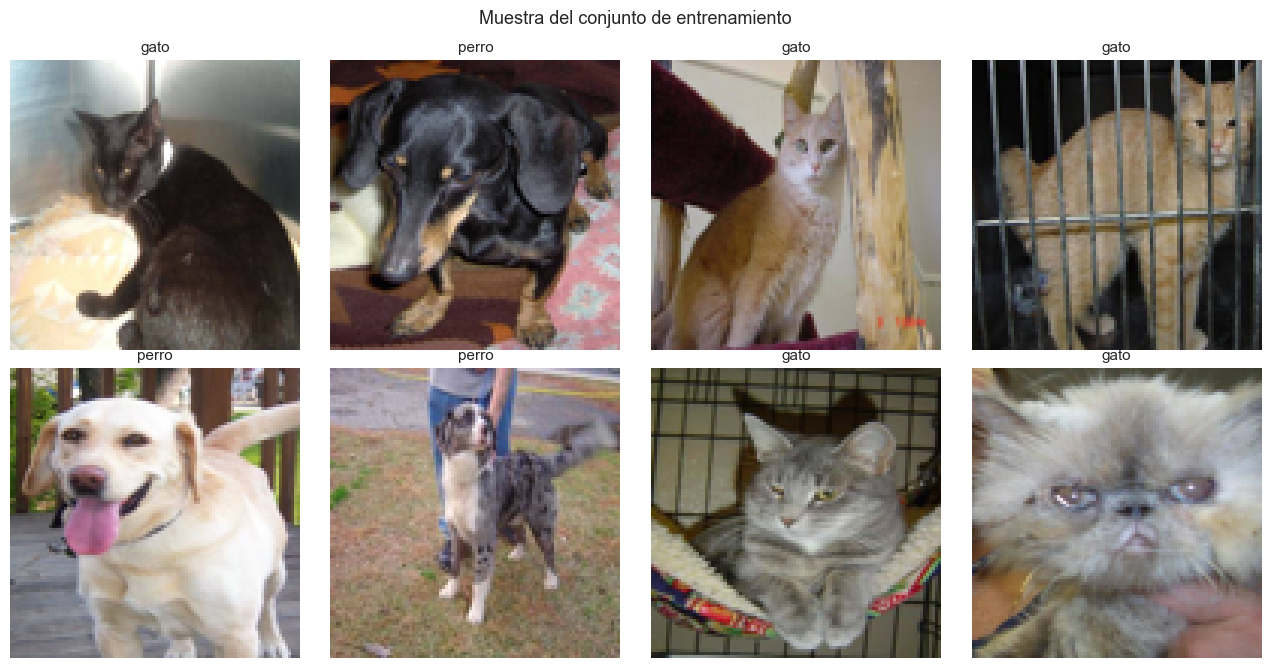

In [4]:
def mostrar_instancias(X, y, n=8, titulo="", predicciones=None):
    """Pinta n imágenes con su etiqueta (y opcionalmente la predicción)."""
    indices = np.random.choice(len(X), size=n, replace=False)
    filas = int(np.ceil(n / 4))
    fig, axes = plt.subplots(filas, 4, figsize=(13, 3.4 * filas))
    for ax, i in zip(np.atleast_1d(axes).ravel(), indices):
        # si viene escalado (float 0-1) matplotlib lo pinta igual de bien
        ax.imshow(X[i])
        if predicciones is None:
            ax.set_title(CLASES[y[i]], fontsize=11)
        else:
            acierto = predicciones[i] == y[i]
            ax.set_title(f"real: {CLASES[y[i]]}\npred: {CLASES[predicciones[i]]}",
                         fontsize=10, color="green" if acierto else "red")
        ax.axis("off")
    for ax in np.atleast_1d(axes).ravel()[n:]:
        ax.axis("off")
    if titulo:
        plt.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()


np.random.seed(42)
mostrar_instancias(X_full, y_full, n=8, titulo="Muestra del conjunto de entrenamiento")

Se ve perfectamente la dificultad del problema: los animales aparecen en **posturas y
posiciones completamente distintas**, con fondos que no se parecen en nada y encuadres que
van del primer plano al cuerpo entero. No hay dos imágenes alineadas, al contrario de lo que
pasaba con los dígitos de MNIST, que estaban todos centrados y del mismo tamaño.

**Esto es justo lo que justifica usar convoluciones.** Un MLP aprende un peso por píxel, así
que para él "oreja de gato en la esquina superior izquierda" y "oreja de gato en el centro"
son dos cosas sin ninguna relación. Un filtro convolucional, en cambio, **recorre toda la
imagen buscando el mismo patrón**, sin importar dónde esté.

### 2.3 Tamaños originales

Compruebo qué tamaños traían las fotos antes de redimensionarlas, para confirmar que el
redimensionado era necesario.

Tamaños distintos en una muestra de 200 imágenes: 153
Ancho: de 96 a 500 px (media 400)
Alto : de 71 a 500 px (media 348)


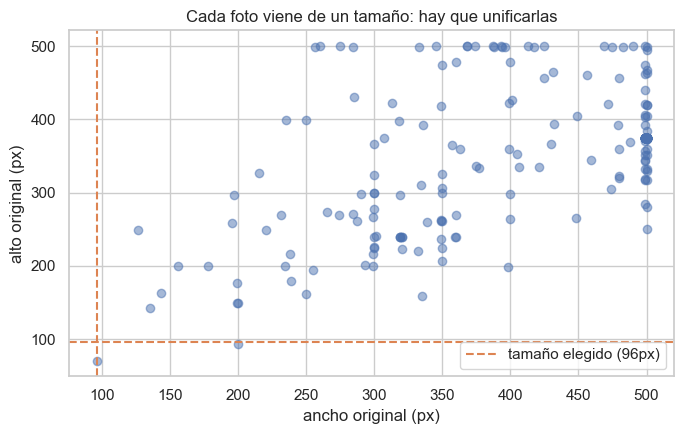

In [5]:
muestra_rutas = sorted(glob.glob("./data/github_train_*/*.jpg"))[:200]
tamanos = [Image.open(r).size for r in muestra_rutas]
anchos = [t[0] for t in tamanos]
altos = [t[1] for t in tamanos]

print(f"Tamaños distintos en una muestra de {len(tamanos)} imágenes: {len(set(tamanos))}")
print(f"Ancho: de {min(anchos)} a {max(anchos)} px (media {np.mean(anchos):.0f})")
print(f"Alto : de {min(altos)} a {max(altos)} px (media {np.mean(altos):.0f})")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(anchos, altos, alpha=0.5, color="#4c72b0")
ax.axvline(TAMANO, color="#dd8452", linestyle="--", label=f"tamaño elegido ({TAMANO}px)")
ax.axhline(TAMANO, color="#dd8452", linestyle="--")
ax.set_xlabel("ancho original (px)")
ax.set_ylabel("alto original (px)")
ax.set_title("Cada foto viene de un tamaño: hay que unificarlas")
ax.legend()
plt.tight_layout()
plt.show()

Confirmado: prácticamente **cada foto tiene un tamaño distinto**. Por eso el
redimensionado del paso 1 no es un capricho, es imprescindible para poder apilarlas en un
único array.

## 3. Preparar los datos

### 3.1 Escalado

Paso los píxeles de `[0, 255]` a `[0, 1]` dividiendo por 255. Es el mismo escalado que
hice en la unidad de Keras: las redes convergen mucho peor con valores de entrada
grandes, porque los gradientes se disparan.

In [6]:
X_full_esc = X_full.astype("float32") / 255.0
X_test_esc = X_test.astype("float32") / 255.0

print(f"Rango tras escalar: {X_full_esc.min():.1f} a {X_full_esc.max():.1f}")
print(f"Memoria que ocupa el train: {X_full_esc.nbytes / 1e6:.1f} MB")

Rango tras escalar: 0.0 a 1.0
Memoria que ocupa el train: 115.1 MB


### 3.2 La trampa del split de validación

Aquí está el detalle que avisaba el enunciado, y es un error muy fácil de cometer.

Las imágenes se han cargado recorriendo los directorios **en orden**: primero
`github_train_0` y `github_train_1`, que son **todo gatos**, y después `github_train_2` y
`github_train_3`, que son **todo perros**. Es decir, el array `y_full` está **ordenado por
clase**.

Y resulta que el parámetro `validation_split` de Keras **coge el último X% de los datos tal
cual, sin barajar**. Usándolo aquí, el conjunto de validación sería **100% perros** y la
`val_accuracy` no significaría absolutamente nada.

Lo compruebo antes de nada:

In [7]:
print("Primeras 10 etiquetas :", y_full[:10], "-> todo gatos")
print("Últimas 10 etiquetas  :", y_full[-10:], "-> todo perros")

# Lo que pasaria usando validation_split=0.2 sin barajar:
corte = int(len(y_full) * 0.8)
val_ingenua = y_full[corte:]
print(f"\nSi usara validation_split=0.2, la validación tendría: "
      f"{np.bincount(val_ingenua)[0]} gatos y {np.bincount(val_ingenua)[1]} perros")
print("Es decir: una validación de una sola clase. Completamente inútil.")

Primeras 10 etiquetas : [0 0 0 0 0 0 0 0 0 0] -> todo gatos
Últimas 10 etiquetas  : [1 1 1 1 1 1 1 1 1 1] -> todo perros

Si usara validation_split=0.2, la validación tendría: 0 gatos y 209 perros
Es decir: una validación de una sola clase. Completamente inútil.


**La solución:** hacer el split con `train_test_split` de sklearn, que **baraja por
defecto**, y además usar `stratify=y` para garantizar que la proporción de gatos y perros
sea la misma en train y en validación.

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X_full_esc, y_full,
    test_size=0.2,
    stratify=y_full,     # misma proporcion de clases en ambos conjuntos
    random_state=42,
)

print(f"Train     : {X_train.shape[0]} imágenes -> {np.bincount(y_train)} (gatos, perros)")
print(f"Validación: {X_val.shape[0]} imágenes -> {np.bincount(y_val)} (gatos, perros)")
print(f"Test      : {X_test_esc.shape[0]} imágenes -> {np.bincount(y_test)} (gatos, perros)")
print("\nAhora sí: la validación está equilibrada y la val_accuracy será interpretable.")

Train     : 832 imágenes -> [432 400] (gatos, perros)
Validación: 209 imágenes -> [109 100] (gatos, perros)
Test      : 257 imágenes -> [119 138] (gatos, perros)

Ahora sí: la validación está equilibrada y la val_accuracy será interpretable.


## 4. Baseline: una red densa (MLP)

Antes de montar la CNN, entreno una red densa como las de la unidad anterior. No espero que
funcione bien: quiero **medir cuánto aporta realmente la convolución**, y para eso necesito
una referencia.

La capa `Flatten` convierte cada imagen de 96x96x3 en un vector de 27.648 números. Eso tiene
dos consecuencias graves:

1. **Se pierde toda la estructura espacial.** Dos píxeles vecinos acaban en posiciones
   arbitrarias del vector; la red no tiene forma de saber que estaban juntos.
2. **El número de parámetros se dispara.** Solo la primera capa densa de 128 neuronas ya
   necesita 27.648 × 128 ≈ 3,5 millones de pesos.

In [9]:
mlp = keras.Sequential([
    layers.Input(shape=(TAMANO, TAMANO, 3)),
    layers.Flatten(),                             # aplana: se pierde la estructura 2D
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid"),        # binaria: 1 neurona + sigmoid
], name="MLP_baseline")

mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",                   # binaria: binary_crossentropy
    metrics=["accuracy"],
)

mlp.summary()

Model: "MLP_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 27648)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,539,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,547,393 (13.53 MB)

 Trainable params: 3,547,393 (13.53 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
t0 = time.time()
hist_mlp = mlp.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=0,
)
print(f"Entrenado en {time.time() - t0:.0f} segundos")

acc_mlp_val = max(hist_mlp.history["val_accuracy"])
acc_mlp_test = mlp.evaluate(X_test_esc, y_test, verbose=0)[1]
print(f"\nMLP -> mejor val_accuracy: {acc_mlp_val:.3f} | accuracy en test: {acc_mlp_test:.3f}")
print(f"Recordatorio: el baseline trivial era {baseline_trivial:.3f}")

Entrenado en 25 segundos

MLP -> mejor val_accuracy: 0.522 | accuracy en test: 0.494
Recordatorio: el baseline trivial era 0.537


**El MLP no llega ni al baseline trivial** (0.494 contra 0.537): lo haría mejor un modelo
que dijera siempre "perro" sin mirar la foto. Con 3,5 millones de parámetros y solo 832
imágenes de entrenamiento, la red tiene muchísima más capacidad que datos: se aprende el
ruido de las fotos concretas de train y no generaliza absolutamente nada.

Este es exactamente el problema que resuelven las convoluciones.

## 5. La CNN desde cero

### 5.1 Topología

Sigo el esquema clásico visto en el workout, repitiendo el bloque
**`Conv2D` → `MaxPool2D`** varias veces y aumentando el número de filtros a medida que se
avanza:

| Capa | Qué hace | Por qué |
|---|---|---|
| `Conv2D(32, 3x3)` | 32 filtros que recorren la imagen | Detectan patrones **locales** (bordes, texturas) **en cualquier posición** |
| `MaxPool2D(2x2)` | Reduce el tamaño a la mitad | Menos parámetros y cierta tolerancia a pequeños desplazamientos |
| `Conv2D(64)`, `Conv2D(128)` | Más filtros, imagen más pequeña | Las capas profundas combinan los patrones simples en otros complejos (orejas, hocicos) |
| `Flatten` | Aplana el resultado final | Para conectarlo con la parte densa |
| `Dropout(0.5)` | Apaga la mitad de las neuronas en cada paso | Es la defensa principal contra el sobreajuste |
| `Dense(1, sigmoid)` | Una sola salida entre 0 y 1 | Clasificación **binaria**: probabilidad de que sea perro |

**Por qué los filtros crecen (32 → 64 → 128) mientras la imagen se encoge:** al principio la
red busca pocos patrones muy simples sobre una imagen grande; según avanza, la resolución
baja pero la variedad de patrones que hay que representar aumenta.

In [11]:
def construir_cnn(con_augmentation=False, nombre="CNN"):
    """Construye la CNN. El bloque de augmentation es opcional."""
    capas = [layers.Input(shape=(TAMANO, TAMANO, 3))]

    if con_augmentation:
        capas.append(keras.Sequential([
            layers.RandomFlip("horizontal"),      # un gato del reves sigue siendo un gato
            layers.RandomRotation(0.12),
            layers.RandomZoom(0.15),
            layers.RandomTranslation(0.1, 0.1),
        ], name="augmentation"))

    capas += [
        # Bloque 1
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPool2D((2, 2)),

        # Bloque 2
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPool2D((2, 2)),

        # Bloque 3
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPool2D((2, 2)),

        # Bloque 4
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.MaxPool2D((2, 2)),

        # Cabeza densa
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]

    modelo = keras.Sequential(capas, name=nombre)
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return modelo


cnn = construir_cnn(con_augmentation=False, nombre="CNN_sin_augmentation")
cnn.summary()

print(f"\nParámetros de la CNN: {cnn.count_params():,}")
print(f"Parámetros del MLP  : {mlp.count_params():,}")
print("\nLa CNN tiene MENOS parámetros que el MLP y aun así va a funcionar mucho mejor:")
print("los filtros se reutilizan en toda la imagen en vez de tener un peso por píxel.")

Model: "CNN_sin_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 831,809 (3.17 MB)

 Trainable params: 831,361 (3.17 MB)

 Non-trainable params: 448 (1.75 KB)


Parámetros de la CNN: 831,809
Parámetros del MLP  : 3,547,393

La CNN tiene MENOS parámetros que el MLP y aun así va a funcionar mucho mejor:
los filtros se reutilizan en toda la imagen en vez de tener un peso por píxel.


### 5.2 Entrenamiento

In [12]:
t0 = time.time()
hist_cnn = cnn.fit(
    X_train, y_train,
    epochs=25,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=0,
)
print(f"Entrenada en {time.time() - t0:.0f} segundos")

acc_cnn_val = max(hist_cnn.history["val_accuracy"])
acc_cnn_test = cnn.evaluate(X_test_esc, y_test, verbose=0)[1]
print(f"\nCNN -> mejor val_accuracy: {acc_cnn_val:.3f} | accuracy en test: {acc_cnn_test:.3f}")
print(f"MLP -> mejor val_accuracy: {acc_mlp_val:.3f} | accuracy en test: {acc_mlp_test:.3f}")

Entrenada en 217 segundos



CNN -> mejor val_accuracy: 0.684 | accuracy en test: 0.650
MLP -> mejor val_accuracy: 0.522 | accuracy en test: 0.494


### 5.3 Curvas de aprendizaje: el diagnóstico

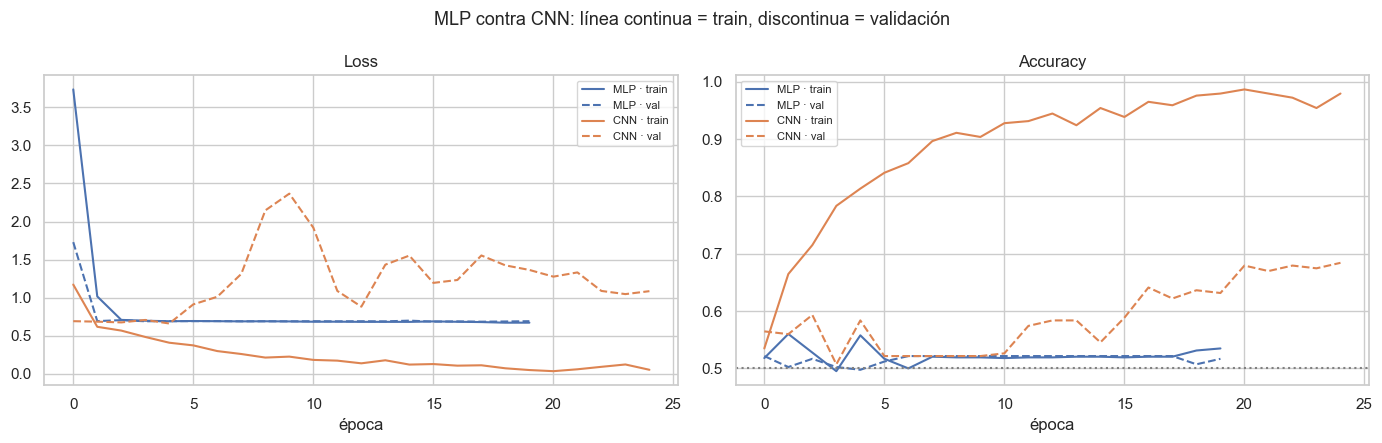

Brecha final train - validación de la CNN: 0.295


In [13]:
def pintar_curvas(historiales, titulo):
    """Pinta loss y accuracy de uno o varios entrenamientos."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    colores = ["#4c72b0", "#dd8452", "#55a868"]

    for (nombre, h), color in zip(historiales.items(), colores):
        axes[0].plot(h.history["loss"], color=color, label=f"{nombre} · train")
        axes[0].plot(h.history["val_loss"], color=color, linestyle="--", label=f"{nombre} · val")
        axes[1].plot(h.history["accuracy"], color=color, label=f"{nombre} · train")
        axes[1].plot(h.history["val_accuracy"], color=color, linestyle="--", label=f"{nombre} · val")

    axes[0].set_title("Loss"); axes[0].set_xlabel("época"); axes[0].legend(fontsize=8)
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("época"); axes[1].legend(fontsize=8)
    axes[1].axhline(0.5, color="grey", linestyle=":", label="azar")
    plt.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()


pintar_curvas({"MLP": hist_mlp, "CNN": hist_cnn},
              "MLP contra CNN: línea continua = train, discontinua = validación")

brecha = hist_cnn.history["accuracy"][-1] - hist_cnn.history["val_accuracy"][-1]
print(f"Brecha final train - validación de la CNN: {brecha:.3f}")

**El diagnóstico está claro en las curvas:** la accuracy de train de la CNN sube hacia 1,0
mientras la de validación se estanca, y la loss de validación empieza a **subir** en vez de
bajar. Eso es **sobreajuste de libro**: la red se está memorizando las 832 imágenes de
entrenamiento.

Es lo esperable: los modelos que resuelven bien este problema se entrenan con **25.000**
imágenes, y aquí hay el 4% de eso.

**Cómo se ataca sin conseguir más fotos:** con **data augmentation**.

## 6. CNN con data augmentation

La idea es generar variaciones de las imágenes disponibles para que la red **nunca vea dos
veces exactamente la misma foto**:

| Transformación | Por qué tiene sentido aquí |
|---|---|
| `RandomFlip("horizontal")` | Un gato mirando a la izquierda sigue siendo un gato. **Solo horizontal**: un animal boca abajo no es una foto realista |
| `RandomRotation(0.12)` | Pequeñas inclinaciones de cámara, hasta ±43º |
| `RandomZoom(0.15)` | El animal puede estar más cerca o más lejos |
| `RandomTranslation(0.1, 0.1)` | El animal no siempre está centrado |

**Un detalle importante:** las capas de augmentation van **dentro del modelo**, así que solo
se aplican durante el entrenamiento. En validación y en test Keras las desactiva
automáticamente — evaluar sobre imágenes distorsionadas no tendría ningún sentido.

Añado también un `EarlyStopping` que para el entrenamiento cuando la validación deja de
mejorar y **restaura los mejores pesos**, en vez de quedarse con los de la última época.

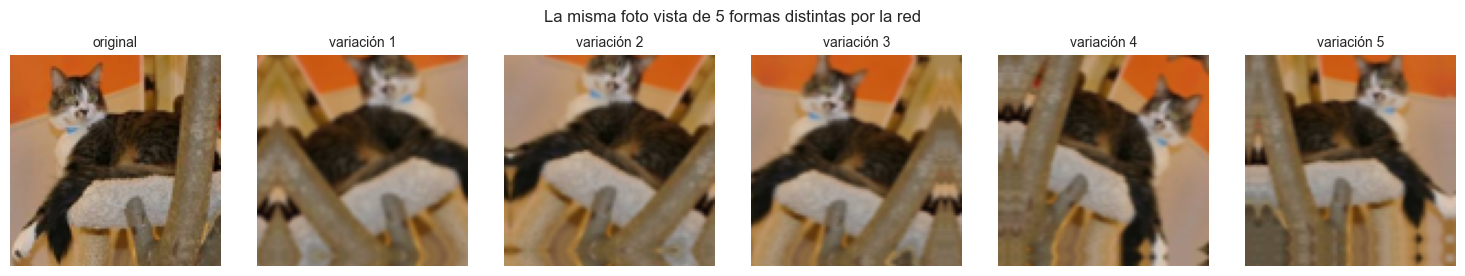

In [14]:
# Asi se ve el augmentation aplicado a una misma imagen
aug_demo = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
])

original = X_train[0:1]
fig, axes = plt.subplots(1, 6, figsize=(15, 2.8))
axes[0].imshow(original[0]); axes[0].set_title("original", fontsize=10); axes[0].axis("off")
for i in range(1, 6):
    axes[i].imshow(aug_demo(original, training=True)[0].numpy())
    axes[i].set_title(f"variación {i}", fontsize=10)
    axes[i].axis("off")
plt.suptitle("La misma foto vista de 5 formas distintas por la red", fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
cnn_aug = construir_cnn(con_augmentation=True, nombre="CNN_con_augmentation")

parada = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=15,                  # aguanta 15 epocas sin mejorar antes de parar
    restore_best_weights=True,    # se queda con los mejores pesos, no con los ultimos
)

t0 = time.time()
hist_aug = cnn_aug.fit(
    X_train, y_train,
    epochs=70,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[parada],
    verbose=0,
)
print(f"Entrenada en {time.time() - t0:.0f} segundos "
      f"({len(hist_aug.history['loss'])} épocas de las 70 permitidas)")

acc_aug_val = max(hist_aug.history["val_accuracy"])
acc_aug_test = cnn_aug.evaluate(X_test_esc, y_test, verbose=0)[1]
print(f"\nCNN + augmentation -> val: {acc_aug_val:.3f} | test: {acc_aug_test:.3f}")

Entrenada en 430 segundos (46 épocas de las 70 permitidas)



CNN + augmentation -> val: 0.780 | test: 0.716


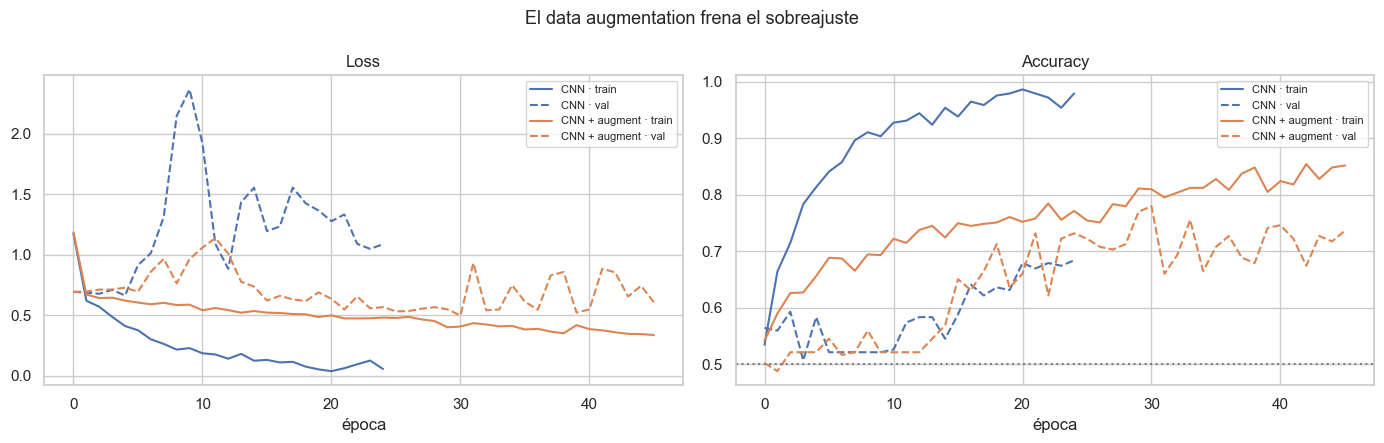

Brecha train - validación SIN augmentation: 0.295
Brecha train - validación CON augmentation: 0.115


In [16]:
pintar_curvas({"CNN": hist_cnn, "CNN + augment": hist_aug},
              "El data augmentation frena el sobreajuste")

brecha_aug = (hist_aug.history["accuracy"][-1] - hist_aug.history["val_accuracy"][-1])
print(f"Brecha train - validación SIN augmentation: {brecha:.3f}")
print(f"Brecha train - validación CON augmentation: {brecha_aug:.3f}")

### Comparativa de los tres modelos

In [17]:
import pandas as pd

comparativa = pd.DataFrame([
    {"modelo": "Baseline trivial", "parametros": 0,
     "val_accuracy": np.nan, "test_accuracy": round(baseline_trivial, 3)},
    {"modelo": "MLP (red densa)", "parametros": mlp.count_params(),
     "val_accuracy": round(acc_mlp_val, 3), "test_accuracy": round(acc_mlp_test, 3)},
    {"modelo": "CNN", "parametros": cnn.count_params(),
     "val_accuracy": round(acc_cnn_val, 3), "test_accuracy": round(acc_cnn_test, 3)},
    {"modelo": "CNN + augmentation", "parametros": cnn_aug.count_params(),
     "val_accuracy": round(acc_aug_val, 3), "test_accuracy": round(acc_aug_test, 3)},
])
display(comparativa)

mejor = comparativa.loc[comparativa["test_accuracy"].idxmax(), "modelo"]
print(f"Mejor modelo sobre el test: {mejor}")

,modelo,parametros,val_accuracy,test_accuracy
0,Baseline trivial,0,NaN,0.537
1,MLP (red densa),3547393,0.522,0.494
2,CNN,831809,0.684,0.650
3,CNN + augmentation,831809,0.780,0.716


Mejor modelo sobre el test: CNN + augmentation


## 7. Evaluación final contra el test

Las 257 imágenes de `github_test/` no se han usado en ningún momento: ni para entrenar ni
para elegir cuándo parar. Es la primera vez que el modelo las ve.

In [18]:
# El modelo devuelve una probabilidad; 0.5 es el umbral por defecto
probabilidades = cnn_aug.predict(X_test_esc, verbose=0).ravel()
predicciones = (probabilidades >= 0.5).astype(int)

print("=== INFORME DE CLASIFICACIÓN (test) ===")
print(classification_report(y_test, predicciones, target_names=CLASES, digits=3))

=== INFORME DE CLASIFICACIÓN (test) ===
              precision    recall  f1-score   support

        gato      0.667     0.773     0.716       119
       perro      0.773     0.667     0.716       138

    accuracy                          0.716       257
   macro avg      0.720     0.720     0.716       257
weighted avg      0.724     0.716     0.716       257



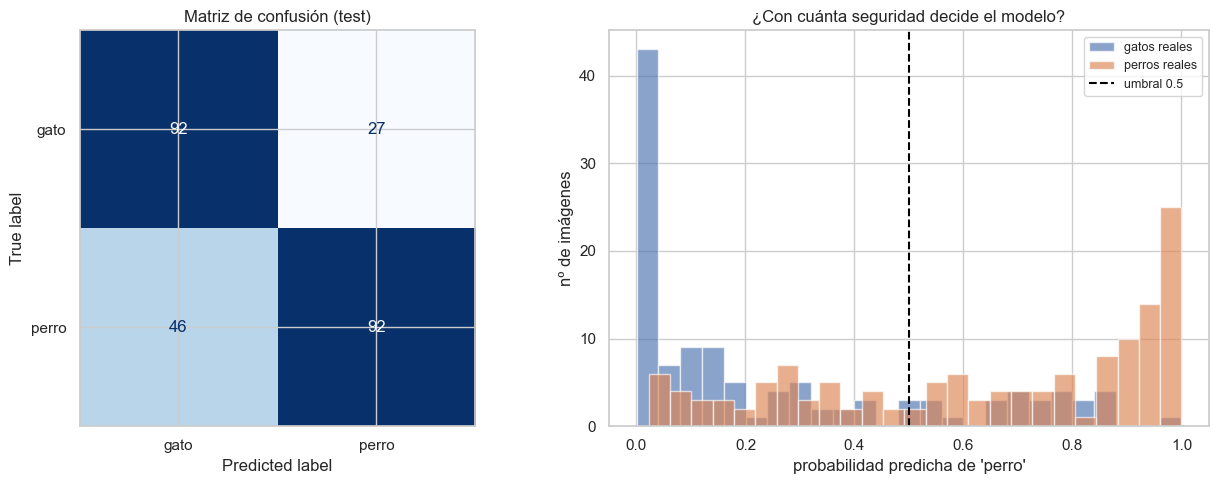

Gatos clasificados como perros: 27 de 119
Perros clasificados como gatos: 46 de 138


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, predicciones, display_labels=CLASES, ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de confusión (test)")

axes[1].hist(probabilidades[y_test == 0], bins=25, alpha=0.65, label="gatos reales", color="#4c72b0")
axes[1].hist(probabilidades[y_test == 1], bins=25, alpha=0.65, label="perros reales", color="#dd8452")
axes[1].axvline(0.5, color="black", linestyle="--", label="umbral 0.5")
axes[1].set_xlabel("probabilidad predicha de 'perro'")
axes[1].set_ylabel("nº de imágenes")
axes[1].set_title("¿Con cuánta seguridad decide el modelo?")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, predicciones)
print(f"Gatos clasificados como perros: {cm[0, 1]} de {cm[0].sum()}")
print(f"Perros clasificados como gatos: {cm[1, 0]} de {cm[1].sum()}")

El histograma de la derecha es tan informativo como la matriz de confusión: si las dos
distribuciones estuvieran bien separadas hacia 0 y hacia 1, el modelo estaría **seguro** de
sus decisiones. Cuanta más masa se acumula alrededor de 0,5, más está el modelo "dudando".

### Aciertos y errores

Aciertos: 184 | Fallos: 73 de 257 imágenes


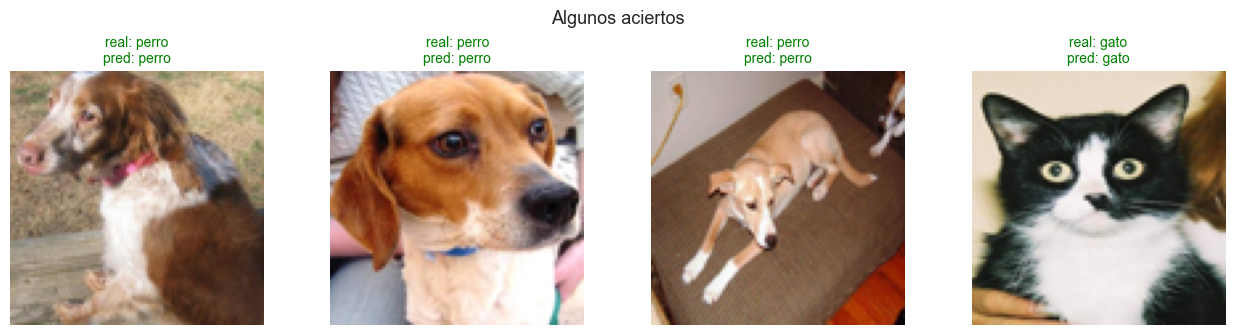

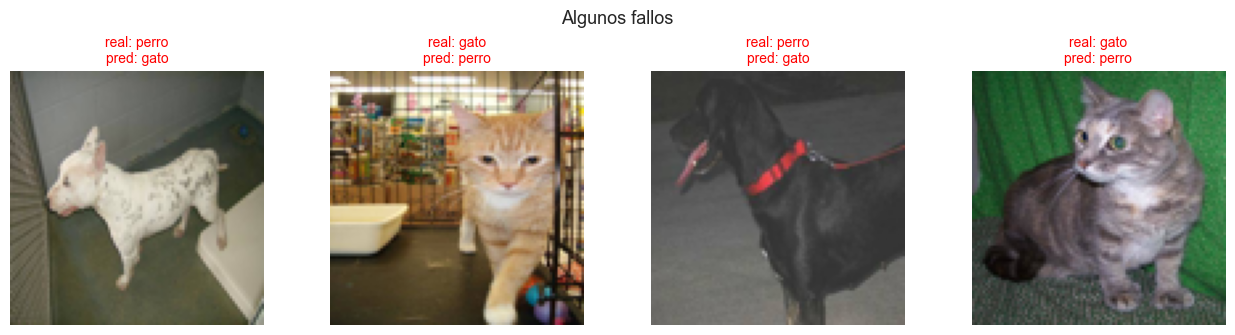

In [20]:
np.random.seed(7)
aciertos = np.where(predicciones == y_test)[0]
fallos = np.where(predicciones != y_test)[0]

print(f"Aciertos: {len(aciertos)} | Fallos: {len(fallos)} de {len(y_test)} imágenes")

mostrar_instancias(X_test_esc[aciertos], y_test[aciertos], n=4,
                   titulo="Algunos aciertos", predicciones=predicciones[aciertos])
mostrar_instancias(X_test_esc[fallos], y_test[fallos], n=4,
                   titulo="Algunos fallos", predicciones=predicciones[fallos])

### EXTRA: los errores más confiados

Los fallos que más preocupan no son los de probabilidad 0,51 —ahí el modelo ya estaba
dudando—, sino aquellos en los que **se equivoca estando convencido**.

Errores con más de un 90% de confianza: 11 de 73 errores totales


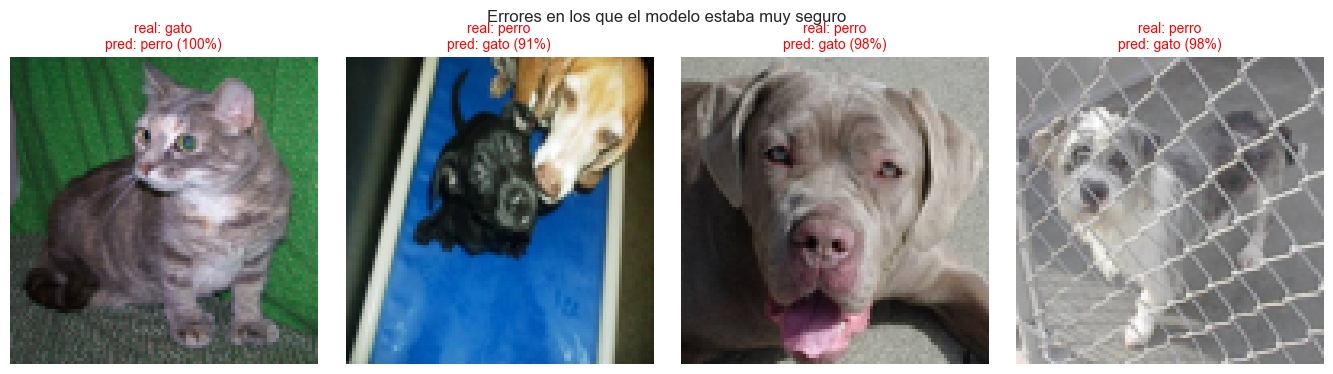

In [21]:
# confianza en la clase que el modelo eligio
confianza = np.where(predicciones == 1, probabilidades, 1 - probabilidades)
fallos_confiados = [i for i in fallos if confianza[i] > 0.9]

print(f"Errores con más de un 90% de confianza: {len(fallos_confiados)} "
      f"de {len(fallos)} errores totales")

if fallos_confiados:
    idx = np.array(fallos_confiados[:4])
    fig, axes = plt.subplots(1, len(idx), figsize=(3.4 * len(idx), 3.8))
    for ax, i in zip(np.atleast_1d(axes), idx):
        ax.imshow(X_test_esc[i])
        ax.set_title(f"real: {CLASES[y_test[i]]}\npred: {CLASES[predicciones[i]]} "
                     f"({confianza[i]*100:.0f}%)", fontsize=10, color="red")
        ax.axis("off")
    plt.suptitle("Errores en los que el modelo estaba muy seguro", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No hay errores con tanta confianza: el modelo duda en los casos que falla,")
    print("que es justo el comportamiento deseable.")

## 8. Conclusiones

**1. La convolución es lo que resuelve el problema, no el tamaño de la red.** El MLP tiene
*más* parámetros que la CNN y funciona mucho peor. La diferencia no es capacidad, es
**el sesgo inductivo correcto**: un filtro convolucional busca el mismo patrón por toda la
imagen, mientras que el MLP aprende un peso independiente por píxel y no puede reconocer una
oreja si aparece desplazada.

**2. Con ~1.000 imágenes, el sobreajuste es el enemigo principal.** Las curvas lo enseñan
sin ambigüedad: la accuracy de train se dispara hacia 1,0 mientras la de validación se
estanca y la loss de validación empieza a subir. El `Dropout` no basta por sí solo.

**3. El data augmentation es la herramienta que más aporta aquí**, y no cuesta ni un dato
nuevo: reduce la brecha entre train y validación obligando a la red a no depender de la
orientación, el encuadre o la posición exacta del animal.

**4. El detalle que más fácil se pasa por alto es el split.** Si hubiera usado
`validation_split=0.2` de Keras sin barajar, la validación habría sido **100% perros** y
todas las decisiones posteriores —cuándo parar, qué modelo elegir— se habrían tomado sobre
una métrica sin sentido. Y lo peor es que el entrenamiento no habría dado ningún error:
habría "funcionado" perfectamente dando números falsos.

**5. El techo lo pone el dato, no la arquitectura.** Este problema se resuelve con más del
95% de accuracy, pero usando **25.000 imágenes**: aquí hay el 4% de esas. Con este volumen,
lo honesto es reconocer que una CNN entrenada desde cero llega hasta donde llega.

### Cómo se mejoraría

| Vía | Qué aportaría |
|---|---|
| **Transfer learning** (es justo el tema de la Unidad 2) | Partir de una red preentrenada con millones de imágenes y reaprovechar sus filtros. Es, con diferencia, la mejora más grande posible aquí |
| Más imágenes del dataset original de Kaggle | El remedio de fondo al sobreajuste |
| Resolución mayor (160x160 o 224x224) | Más detalle para distinguir hocicos y orejas, a costa de tiempo de cómputo |
| Ajustar el umbral de decisión | Si un tipo de error costara más que el otro, moverlo del 0,5 por defecto |